In [19]:
from google.colab import files

# Esto abrirá el selector de archivos
uploaded = files.upload()

# Una vez cargado, puedes verificar el nombre del archivo
for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving MATAMOROS.csv to MATAMOROS.csv
User uploaded file "MATAMOROS.csv" with length 5474 bytes


In [20]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# 1. Cargar los datos
df = pd.read_csv('TAMPICO.csv')
data = df['temperature'].values.reshape(-1, 1)

# 2. Definir los puntos de corte (70%, 20%, 10%) para N=324
# Entrenamiento: 227 meses
# Validación: 65 meses
# Prueba: 32 meses
n_total = len(data)
n_train = 227
n_val = 65
n_test = 32

train_data = data[:n_train]
val_data = data[n_train:n_train + n_val]
test_data = data[n_train + n_val:]

# 3. Escalamiento Profesional (Blindado contra Data Leakage)
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(train_data) # El fit solo se hace con el entrenamiento

train_scaled = scaler.transform(train_data)
val_scaled = scaler.transform(val_data)
test_scaled = scaler.transform(test_data)

# 4. Función para crear el Aprendizaje Supervisado (L=12 para pronosticar 1)
def create_sequences(data, L=12):
    X, y = [], []
    for i in range(len(data) - L):
        X.append(data[i:(i + L), 0])
        y.append(data[i + L, 0])
    return np.array(X), np.array(y)

L = 12
X_train, y_train = create_sequences(train_scaled, L)
X_val, y_val = create_sequences(val_scaled, L)
X_test, y_test = create_sequences(test_scaled, L)

# Reshape para la LSTM: [samples, time_steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_val = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# 5. Verificación de Formas (Shapes) para tu Manuscrito
print(f"--- Dataset: TAMPICO (N={n_total}) ---")
print(f"Conjunto Entrenamiento: {X_train.shape} muestras")
print(f"Conjunto Validación:    {X_val.shape} muestras")
print(f"Conjunto Prueba:        {X_test.shape} muestras")

--- Dataset: TAMPICO (N=324) ---
Conjunto Entrenamiento: (215, 12, 1) muestras
Conjunto Validación:    (53, 12, 1) muestras
Conjunto Prueba:        (20, 12, 1) muestras


In [21]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping

# 1. Definición de la Arquitectura (Expert Heuristic Selection)
model = Sequential([
    # Primera capa LSTM: 64 unidades, con retorno de secuencias para la siguiente capa
    LSTM(64,
         return_sequences=True,
         input_shape=(12, 1),
         kernel_regularizer=regularizers.l2(0.01),
         name='LSTM_Layer_1'),
    Dropout(0.3),

    # Segunda capa LSTM: 32 unidades, no retorna secuencias (va a la capa densa)
    LSTM(32,
         return_sequences=False,
         kernel_regularizer=regularizers.l2(0.01),
         name='LSTM_Layer_2'),
    Dropout(0.3),

    # Capa de salida: 1 neurona con activación ReLU para el pronóstico térmico
    Dense(1, activation='relu', name='Output_Layer')
])

# 2. Compilación del Modelo
# Usamos ADAM como optimizador y MSE como función de pérdida (estándar en regresión)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='mean_squared_error',
              metrics=['mae'])

# 3. Configuración de Early Stopping (Blindaje contra Overfitting)
# Detendrá el entrenamiento si la pérdida de validación no mejora en 30 épocas
early_stop = EarlyStopping(monitor='val_loss',
                           patience=30,
                           restore_best_weights=True,
                           verbose=1)

# 4. Entrenamiento del Modelo
# Batch size de 36 (equivalente a ciclos de 3 años) tal como se reportó en la tabla
history = model.fit(
    X_train, y_train,
    epochs=200,                # Ponemos un límite alto, Early Stopping hará el resto
    batch_size=36,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

# Resumen del modelo para tu manuscrito
model.summary()

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 111ms/step - loss: 1.0728 - mae: 0.3891 - val_loss: 0.8968 - val_mae: 0.2568
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.8835 - mae: 0.2525 - val_loss: 0.8530 - val_mae: 0.2701
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.8395 - mae: 0.2735 - val_loss: 0.7545 - val_mae: 0.2480
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.7446 - mae: 0.2531 - val_loss: 0.6985 - val_mae: 0.2563
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.7073 - mae: 0.2896 - val_loss: 0.6361 - val_mae: 0.2491
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.6353 - mae: 0.2657 - val_loss: 0.5816 - val_mae: 0.2435
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.5813 - mae: 0.2561 - val_loss: 0.5339 - val_mae: 0.2430
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.5294 - mae: 0.2519 - val_loss: 0.4869 - val_mae: 0.2403
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.4944 - mae: 0.2673 - va

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ LSTM_Layer_1 (LSTM)             │ (None, 12, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_Layer_2 (LSTM)             │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 88,037 (343.90 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 58,692 (229.27 KB)

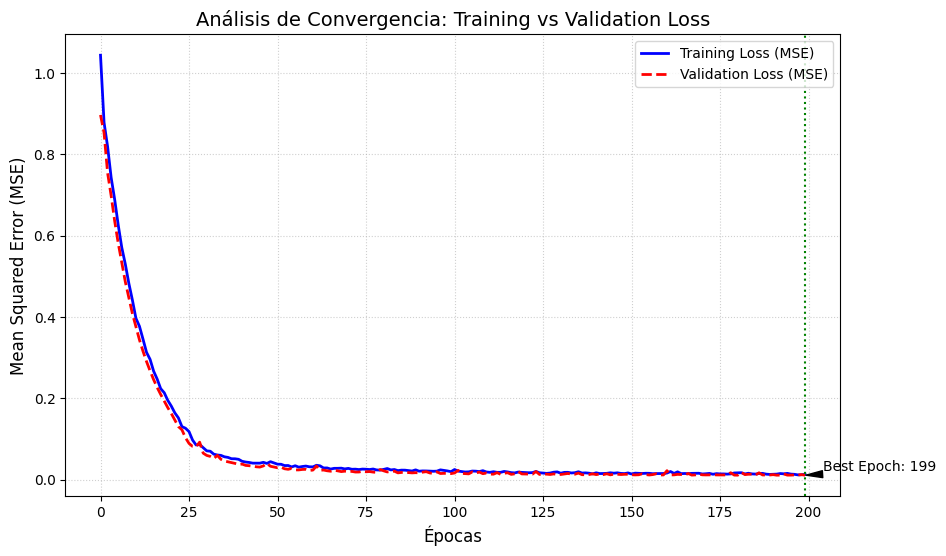

In [22]:
import matplotlib.pyplot as plt

def plot_learning_curves(history):
    plt.figure(figsize=(10, 6))

    # Graficar pérdida de entrenamiento y validación
    plt.plot(history.history['loss'], label='Training Loss (MSE)', color='blue', linewidth=2)
    plt.plot(history.history['val_loss'], label='Validation Loss (MSE)', color='red', linestyle='--', linewidth=2)

    # Personalización técnica para el artículo
    plt.title('Análisis de Convergencia: Training vs Validation Loss', fontsize=14)
    plt.xlabel('Épocas', fontsize=12)
    plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.6)

    # Identificar el punto de Early Stopping
    best_epoch = np.argmin(history.history['val_loss'])
    plt.axvline(x=best_epoch, color='green', linestyle=':', label='Best Model (Early Stopping)')
    plt.annotate(f'Best Epoch: {best_epoch}',
                 xy=(best_epoch, history.history['val_loss'][best_epoch]),
                 xytext=(best_epoch + 5, history.history['val_loss'][best_epoch] + 0.01),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

    plt.show()

# Llamar a la función
plot_learning_curves(history)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step
--- Evaluación Final: Blind Test (N=32) ---
RMSE: 1.4934 °C
MAPE: 5.2394 %
MASE: 0.7229  (Valores < 1 indican que superas al modelo Naive)
DA:   78.95 %


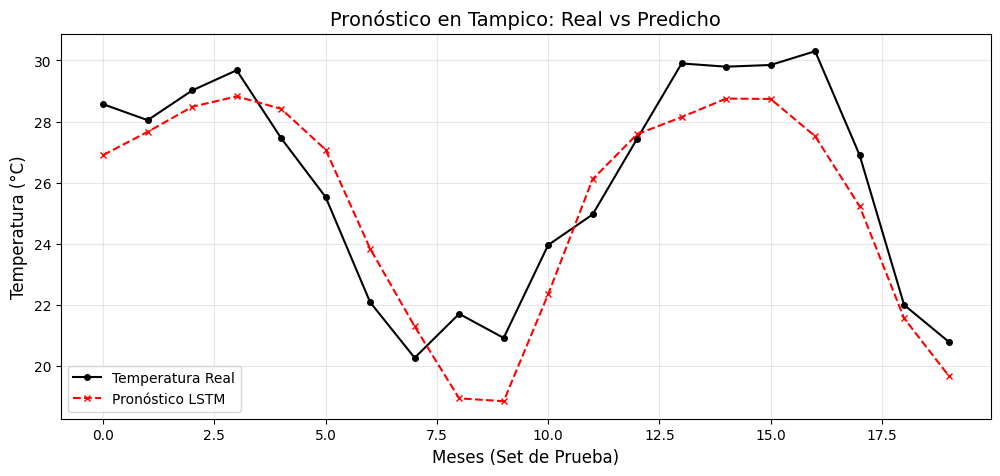

In [23]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Preparar el modelo para el pronóstico
predictions_scaled = model.predict(X_test)

# 2. Des-escalar para volver a unidades reales (Celsius)
# Usamos el scaler que definimos en el bloque anterior
y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1))
predictions_rescaled = scaler.inverse_transform(predictions_scaled)

# 3. Cálculo de Métricas Técnicas
# ---------------------------------------------------------

# RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(y_test_rescaled, predictions_rescaled))

# MAPE (Mean Absolute Percentage Error)
mape = np.mean(np.abs((y_test_rescaled - predictions_rescaled) / y_test_rescaled)) * 100

# DA (Directional Accuracy)
# Compara si el signo del cambio predicho coincide con el cambio real
actual_diff = np.sign(y_test_rescaled[1:] - y_test_rescaled[:-1])
pred_diff = np.sign(predictions_rescaled[1:] - y_test_rescaled[:-1])
da = np.mean(actual_diff == pred_diff) * 100

# MASE (Mean Absolute Scaled Error)
# Necesitamos el MAE del entrenamiento con un modelo Naive (y_t = y_{t-1})
train_rescaled = scaler.inverse_transform(y_train.reshape(-1, 1))
naive_mae_train = np.mean(np.abs(train_rescaled[1:] - train_rescaled[:-1]))
mase = mean_absolute_error(y_test_rescaled, predictions_rescaled) / naive_mae_train

# 4. Reporte de Resultados (Formato para Tabla de Manuscrito)
print(f"--- Evaluación Final: Blind Test (N=32) ---")
print(f"RMSE: {rmse:.4f} °C")
print(f"MAPE: {mape:.4f} %")
print(f"MASE: {mase:.4f}  (Valores < 1 indican que superas al modelo Naive)")
print(f"DA:   {da:.2f} %")

# 5. Gráfica de Comparación (Cierre Visual)
plt.figure(figsize=(12, 5))
plt.plot(y_test_rescaled, label='Temperatura Real', color='black', marker='o', markersize=4)
plt.plot(predictions_rescaled, label='Pronóstico LSTM', color='red', linestyle='--', marker='x', markersize=4)
plt.title(f'Pronóstico en Tampico: Real vs Predicho', fontsize=14)
plt.xlabel('Meses (Set de Prueba)', fontsize=12)
plt.ylabel('Temperatura (°C)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [24]:
import pandas as pd

# --- CONFIGURACIÓN DE METADATOS (Cambia esto para cada corrida) ---
CITY = "MATAMOROS"
VARIABLE = "AVG" # Puede ser MIN, MAX, AVG
MODEL_NAME = "LSTM"

# 1. Crear DataFrame Detallado (Punto a punto)
# ---------------------------------------------------------
df_detailed = pd.DataFrame({
    'City': [CITY] * len(y_test_rescaled),
    'Variable': [VARIABLE] * len(y_test_rescaled),
    'Model': [MODEL_NAME] * len(y_test_rescaled),
    'Actual': y_test_rescaled.flatten(),
    'Forecast': predictions_rescaled.flatten(),
    'Error': (y_test_rescaled - predictions_rescaled).flatten()
})

# Guardar detallado
detailed_filename = f"{CITY}_{VARIABLE}_{MODEL_NAME}_detailed.csv"
df_detailed.to_csv(detailed_filename, index=False)

# 2. Crear DataFrame de Métricas (Resumen para Nemenyi)
# ---------------------------------------------------------
df_metrics = pd.DataFrame({
    'City': [CITY],
    'Variable': [VARIABLE],
    'Model': [MODEL_NAME],
    'RMSE': [rmse],
    'MAPE': [mape],
    'MASE': [mase],
    'DA': [da]
})

# Guardar métricas
metrics_filename = f"{CITY}_{VARIABLE}_{MODEL_NAME}_metrics.csv"
df_metrics.to_csv(metrics_filename, index=False)

# 3. Descarga automática de archivos en Colab
from google.colab import files
files.download(detailed_filename)
files.download(metrics_filename)

print(f"Archivos generados: {detailed_filename} y {metrics_filename}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Archivos generados: MATAMOROS_AVG_LSTM_detailed.csv y MATAMOROS_AVG_LSTM_metrics.csv
